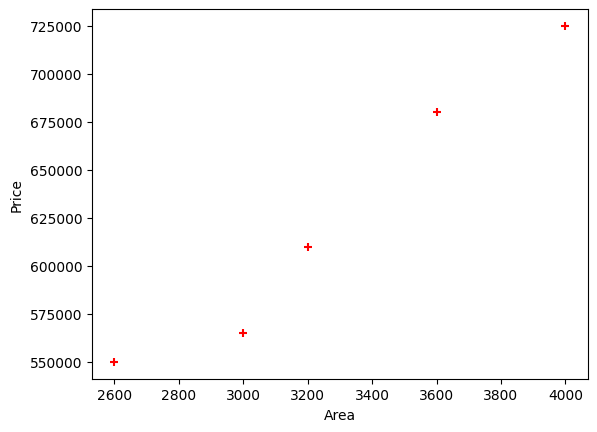

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

df = pd.read_excel("/kaggle/input/datasets/tiksha0505/price-data/price_data.xlsx")
# df

plt.xlabel('Area')
plt.ylabel('Price')

plt.scatter(df.area, df.price, color='red', marker='+')


In [ ]:
# Linear Regression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

df = pd.read_excel("/kaggle/input/datasets/tiksha0505/price-data/price_data.xlsx")

new_df = df.drop('price', axis='columns')
# new_df

model = linear_model.LinearRegression()
model.fit(new_df, df.price)
# model.predict(pd.DataFrame({'area': [3300]}))

result = {"slope": model.coef_, "b": model.intercept_}
# result
# {'slope': array([135.78767123]), 'b': np.float64(180616.43835616432)}

# we know y = m*x+b
# 135.78767123 * 3300 + 180616.43835616432 = 628715.7534151643
# model.predict(pd.DataFrame({'area': [3300]}))

# save the model in file - USING PICKLE
import pickle

with open ("model_home_price", "wb") as file:
    pickle.dump(model, file)
    

with open("model_home_price", "rb") as f:
    mp = pickle.load(f)

mp.coef_

# save the model in file - USING JOBLIB = 
# DIFFERENCE BETWEEN PICKLE AND JOBLIB, IF YOU MORE NUMPY ARRAYS OBJECTS OR NUMERIC VALUES, THEN GO FOR JOBLIB

import joblib
joblib.dump(model, "model_home_joblib")


['model_home_joblib']

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([41288.69409442])

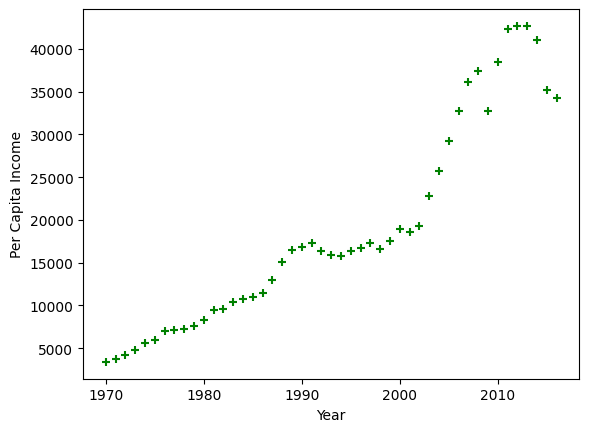

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

df = pd.read_csv("/kaggle/input/datasets/tiksha0505/canada-data/canada_per_capita_income.csv")

plt.xlabel('Year')
plt.ylabel('Per Capita Income')

plt.scatter(df.year, df['per capita income (US$)'], color='green', marker='+')

new_df = df.drop('per capita income (US$)', axis = 'columns')
new_df

model = linear_model.LinearRegression()
model.fit(new_df, df['per capita income (US$)'])

model.predict([[2020]])


In [13]:
# LINEAR REGRESSION WITH MULTIPLE VARIABLES

import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

df = pd.read_excel("/kaggle/input/datasets/tiksha0505/price/price_data.xlsx")
# df

# take median of bedrooms (as per situation) and replace NaN values
df.bedrooms = df.bedrooms.fillna(df.bedrooms.median())
# df

# create and train model
model = linear_model.LinearRegression()
model.fit(df.drop('price', axis='columns'), df.price)

# predict
# model.predict([[3000, 3, 40]]) = array([498408.25158031])

# model.coef_ = array([  112.06244194, 23388.88007794, -3231.71790863])
# model.intercept_ = np.float64(221323.00186540396)

# 3000 * m1 + 3 * m2 + 40 * m3 + b
3000 * 112.06244194 + 3 * 23388.88007794 + 40 * -3231.71790863 + 221323.00186540396 = 498408.251574024


498408.251574024

In [10]:
!pip install word2number

# Exercise
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt
from word2number import w2n
import math


df = pd.read_csv("/kaggle/input/datasets/tiksha0505/hiringdata/hiring.csv")
# df

# cleaning data
df.experience = df.experience.fillna('zero')
df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(math.floor(df['test_score(out of 10)'].mean()))

# first of all i have to convert experience into numerical (integer value) data
df.experience = df.experience.apply(w2n.word_to_num)

# create and train model
model = linear_model.LinearRegression()
model.fit(df.drop('salary($)', axis='columns'), df['salary($)'])

# model.predict([[2, 9, 6]]) = array([53205.96797671]) = with mediam
# model.predict([[12, 10, 10]]) = array([92002.18340611])

# model.predict([[2, 9, 6]])
# model.coef_ = array([2922.26901502, 2221.30909959, 2147.48256637]) = with mean

# model.intercept_ = np.float64(14992.65144669314)

# let's solve for = 12, 10 and 10
# 12 * 2922.26901502 + 10 * 2221.30909959 + 10 * 2147.48256637 + 14992.65144669314

df['test_score(out of 10)'].describe()

count     8.00000
mean      7.75000
std       1.28174
min       6.00000
25%       7.00000
50%       7.50000
75%       8.25000
max      10.00000
Name: test_score(out of 10), dtype: float64

In [7]:
# gradient descent

import numpy as np

def gradient(x, y):
    m_curr = b_curr = 0;
    learning_rate = 0.08;
    n = len(x)
    iterations = 10

    for i in range (iterations):
        y_predict = m_curr * x + b_curr
        cost = (1/n) * sum([val ** 2 for val in (y - y_predict)])
        # y - y_predict will return a vector (array/list) 
        md = -(2/n) * sum(x * (y-y_predict))
        bd = -(2/n) * sum(y-y_predict)

        m_curr = m_curr - learning_rate * md
        b_curr = b_curr - learning_rate * bd

        print("m {}, b {}, cost {}, iteration {}".format(m_curr, b_curr, cost, i))


x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 7, 9, 11, 13])

gradient(x, y)

m 4.96, b 1.44, cost 89.0, iteration 0
m 0.4991999999999983, b 0.26879999999999993, cost 71.10560000000002, iteration 1
m 4.451584000000002, b 1.426176000000001, cost 56.8297702400001, iteration 2
m 0.892231679999997, b 0.5012275199999995, cost 45.43965675929613, iteration 3
m 4.041314713600002, b 1.432759910400001, cost 36.35088701894832, iteration 4
m 1.2008760606719973, b 0.7036872622079998, cost 29.097483330142282, iteration 5
m 3.7095643080294423, b 1.4546767911321612, cost 23.307872849944438, iteration 6
m 1.4424862661541864, b 0.881337636696883, cost 18.685758762535738, iteration 7
m 3.4406683721083144, b 1.4879302070713722, cost 14.994867596913156, iteration 8
m 1.6308855378034224, b 1.0383405553279617, cost 12.046787238456794, iteration 9


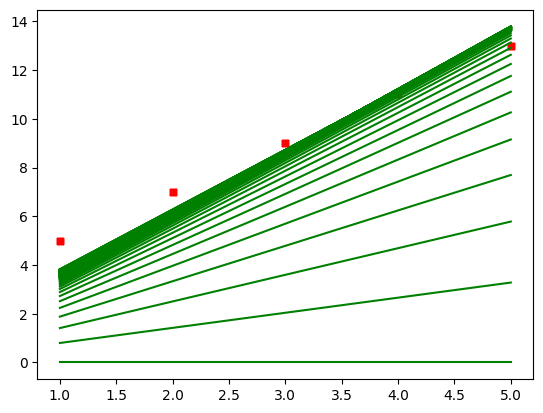

In [18]:
# visual representation of gradient descent

import numpy as np
import matplotlib.pyplot as plt

def gradient(x, y):
    m_curr = b_curr = 0;
    learning_rate = 0.01;
    n = len(x)
    iterations = 100

    plt.scatter(x, y, color='red', marker='+', linewidth=5)
    for i in range (iterations):
        y_predict = m_curr * x + b_curr
        # print m_curr, b_curr and i
        plt.plot(x, y_predict, color='green')
        # plt.show()
        cost = (1/n) * sum([val ** 2 for val in (y - y_predict)])
        # y - y_predict will return a vector (array/list) 
        md = -(2/n) * sum(x * (y-y_predict))
        bd = -(2/n) * sum(y-y_predict)

        m_curr = m_curr - learning_rate * md
        b_curr = b_curr - learning_rate * bd


x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 7, 9, 11, 13])

gradient(x, y)
    

In [14]:
# exercise

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

df = pd.read_csv("/kaggle/input/datasets/tiksha0505/testscores/test_scores.csv")
# df

def gradient(x, y):
    m_curr = b_curr = 0
    learning_rate = 0.0001
    iterations = 100
    n = len(x)

    cost_prev = 0

    for i in range(iterations):
        y_predict = m_curr * x + b_curr

        cost = (1/n) * sum([val ** 2 for val in (y - y_predict)])

        # stop if the cost doesn't make any difference
        if i > 0 and math.isclose(cost_prev, cost, rel_tol=1e-5):
            print(f"Stopping at iteration{i} because cost is too stable")
            break

        cost_prev = cost

        md = -(2/n) * sum(x * (y-y_predict))
        bd = -(2/n) * sum(y-y_predict)

        m_curr = m_curr - learning_rate * md
        b_curr = b_curr - learning_rate * bd

        print("m {}, b {}, cost {}, iteration {}".format(m_curr, b_curr, cost, i))

gradient(df.math, df.cs)

m 0.9891800000000002, b 0.013980000000000001, cost 5199.1, iteration 0
m 1.0416176032, b 0.0147417592, cost 46.3330473650399, iteration 1
m 1.0443971065873279, b 0.014802799669408, cost 31.852649863558305, iteration 2
m 1.0445441606668626, b 0.014826693765467417, cost 31.811952059367805, iteration 3
Stopping at iteration4 because cost is too stable


In [17]:
# DUMMY VARIABLES - USING PANDAS
# using the function = get_dummies

# ONE HOT ENCODING - USING SKLEARN
# using OneHotEncoder

# 
# THE FOLLOWING CODE IS DONE USING PANDAS GET DUMMIES METHOD
# 

import pandas as pd
import numpy as np
df = pd.read_csv("/kaggle/input/datasets/tiksha0505/homeprice/homeprices.csv")

# df
dummies = pd.get_dummies(df.town)
# dummies

df_dummies = pd.concat([df, dummies], axis='columns')
# df_dummies

df_dummies.drop(['town', 'west windsor'], axis='columns', inplace=True)
# df_dummies

X = df_dummies.drop('price', axis='columns')
y = df.price

# X
# y


from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
# model.predict([[3400, 0, 0]])
model.predict([[2800, 0, 1]])

# 
# THE FOLLOWING CODE OF ONE HOT ENCODING IS DONE USING SKLEARN'S  LIBRARY
# 

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

dfle = df.copy()
dfle.town = le.fit_transform(dfle.town)
dfle

# it expects a 2D array
W = dfle[['town', 'area']].values
W

v = dfle.price.values
v

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# ohe = OneHotEncoder(categorical_features=[0]) = deprecated method

ohe = ColumnTransformer(
    transformers = [('town', OneHotEncoder(), [0])],
    remainder = 'passthrough'
)

W = ohe.fit_transform(W)
W

W = W[:, 1:]
W

model2 = LinearRegression()

model2.fit(W, y)
model2.predict([[0, 1, 3400]])

# model2.score(W, y) = 0.9573929037221873
# model.score(X, y) = 0.9573929037221872

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


0.9573929037221872

In [16]:
# Exercise

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv ("/kaggle/input/datasets/tiksha0505/carprice/carprices.csv")
df

# # # plot
# plt.xlabel('Car Model')
# plt.ylabel('Values')
# plt.title('Car Info')

# plt.plot(df['Car Model'], df['Mileage'], label='Mileage', color='green')
# plt.plot(df['Car Model'], df['Sell Price($)'], label='Sell Price', color='red')
# plt.plot(df['Car Model'], df['Age(yrs)'], label='Age', color='blue')

# plt.legend()

dummies = pd.get_dummies(df['Car Model'])
dummies

# concat
df_dummies = pd.concat([df, dummies], axis = 'columns')
df_dummies

# drop unnecessary columns
df_dummies.drop(['Car Model','Mercedez Benz C class'], axis='columns', inplace=True)
df_dummies

from sklearn.linear_model import LinearRegression

model = LinearRegression()

X = df_dummies.drop('Sell Price($)', axis='columns')
y = df['Sell Price($)']
model.fit(X, y)

# model.predict([[45000, 4, 0, 0]]) = array([36991.31721061])
# model.predict([[86000, 7, 0, 1]]) = array([11080.74313219])
# model.score(X, y) = 0.9417050937281082


0.9417050937281082

In [28]:
# train test split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/tiksha0505/car-price-2/carprices (1).csv")
df

# plt.scatter(df['Mileage'], df['Sell Price($)'])
# plt.scatter(df['Age(yrs)'], df['Sell Price($)'])

X = df[['Mileage', 'Age(yrs)']]
X

y = df['Sell Price($)']
y

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3)
X_train

,Mileage,Age(yrs)
15,25400,3
17,69000,5
0,69000,6
10,83000,7
2,57000,5
9,67000,6
7,72000,6
13,58780,4
16,28000,2
1,35000,3


In [14]:
# LOGISTIC REGRESSION - BINARY CLASS

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/tiksha0505/insurance/insurance_data.csv")
df

# plt.scatter(df.age, df.bought_insurance, marker='+', color='red')

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(df[['age']], df.bought_insurance, test_size=0.1)

# X_train
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, Y_train)

# model.predict(X_test)

# model.predict_proba(X_test)
model.score(X_train, Y_train)



0.875

Text(0.5, 1.0, 'Turnover')

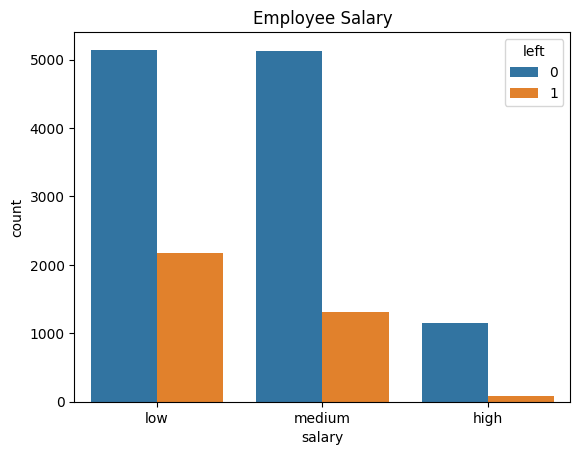

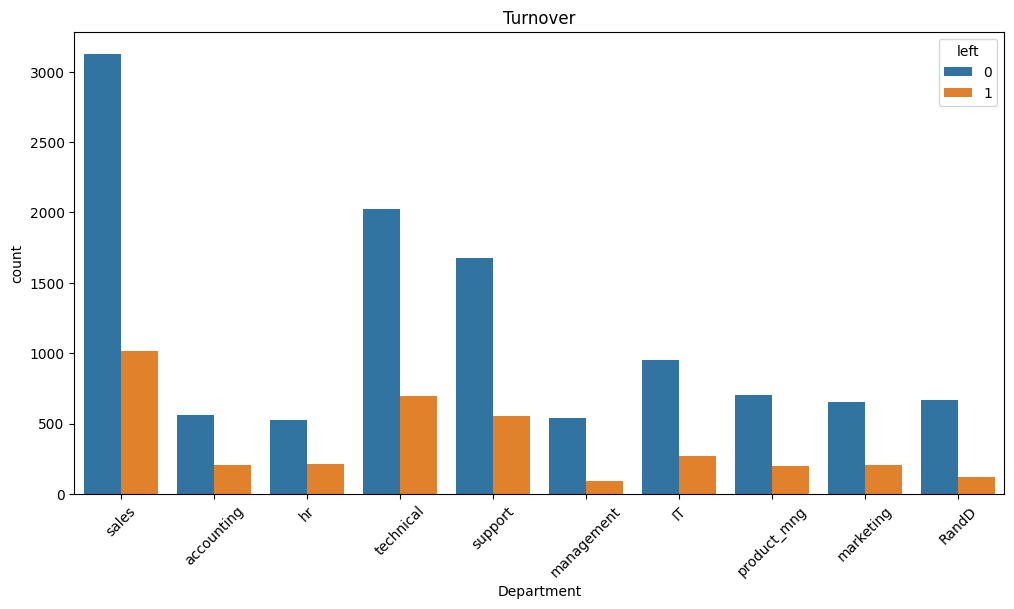

In [10]:
# Exercise

import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/tiksha0505/hr-analytics/HR_comma_sep.csv")
df

df.groupby('left').mean(numeric_only=True)
# satisfaction level, promotion, work accident is different
# average monthly hours is somewhat equivalent, may or may not contribute
# last evaluation, time spend at company and number of projects are almost equal

# calculate impact of salary
import seaborn as sn
sn.countplot(x='salary', hue='left', data=df)
plt.title('Employee Salary')

plt.figure(figsize=(12, 6))
sn.countplot(x='Department', hue='left', data=df)
plt.xticks(rotation=45)
plt.title('Turnover')

In [23]:
# Decision Tree

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/tiksha0505/salarydata/salaries.csv")
# df

inputs = df.drop('salary_more_then_100k', axis='columns')
inputs

target = df['salary_more_then_100k']
target

from sklearn.preprocessing import LabelEncoder
le_company = LabelEncoder()
le_job = LabelEncoder()
le_degree = LabelEncoder()

inputs['company_n'] = le_company.fit_transform(inputs['company'])
inputs['job_n'] = le_job.fit_transform(inputs['job'])
inputs['degree_n'] = le_degree.fit_transform(inputs['degree'])

inputs_n = inputs.drop(['company', 'job', 'degree'], axis='columns',)
inputs_n

# Let's create decision tree model
from sklearn import tree
model = tree.DecisionTreeClassifier()

model.fit(inputs_n, target)

model.score(inputs_n, target)

model.predict([[2, 1, 1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

[Text(0.5, 0.875, 'Sex_n <= 0.5\ngini = 0.472\nsamples = 623\nvalue = [385, 238]'),
 Text(0.25, 0.625, 'Pclass <= 2.5\ngini = 0.383\nsamples = 213\nvalue = [55, 158]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Age <= 2.5\ngini = 0.131\nsamples = 114\nvalue = [8, 106]'),
 Text(0.0625, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1875, 0.125, 'gini = 0.117\nsamples = 112\nvalue = [7, 105]'),
 Text(0.375, 0.375, 'Fare <= 8.04\ngini = 0.499\nsamples = 99\nvalue = [47.0, 52.0]'),
 Text(0.3125, 0.125, 'gini = 0.298\nsamples = 33\nvalue = [6, 27]'),
 Text(0.4375, 0.125, 'gini = 0.471\nsamples = 66\nvalue = [41, 25]'),
 Text(0.75, 0.625, 'Age <= 8.5\ngini = 0.314\nsamples = 410\nvalue = [330, 80]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Pclass <= 2.5\ngini = 0.397\nsamples = 22\nvalue = [6, 16]'),
 Text(0.5625, 0.125, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.6875, 0.125, 'gini = 0.496\nsamples = 11\nvalue = [6, 5]'),
 Text(0.875, 0.375, 'Fare 

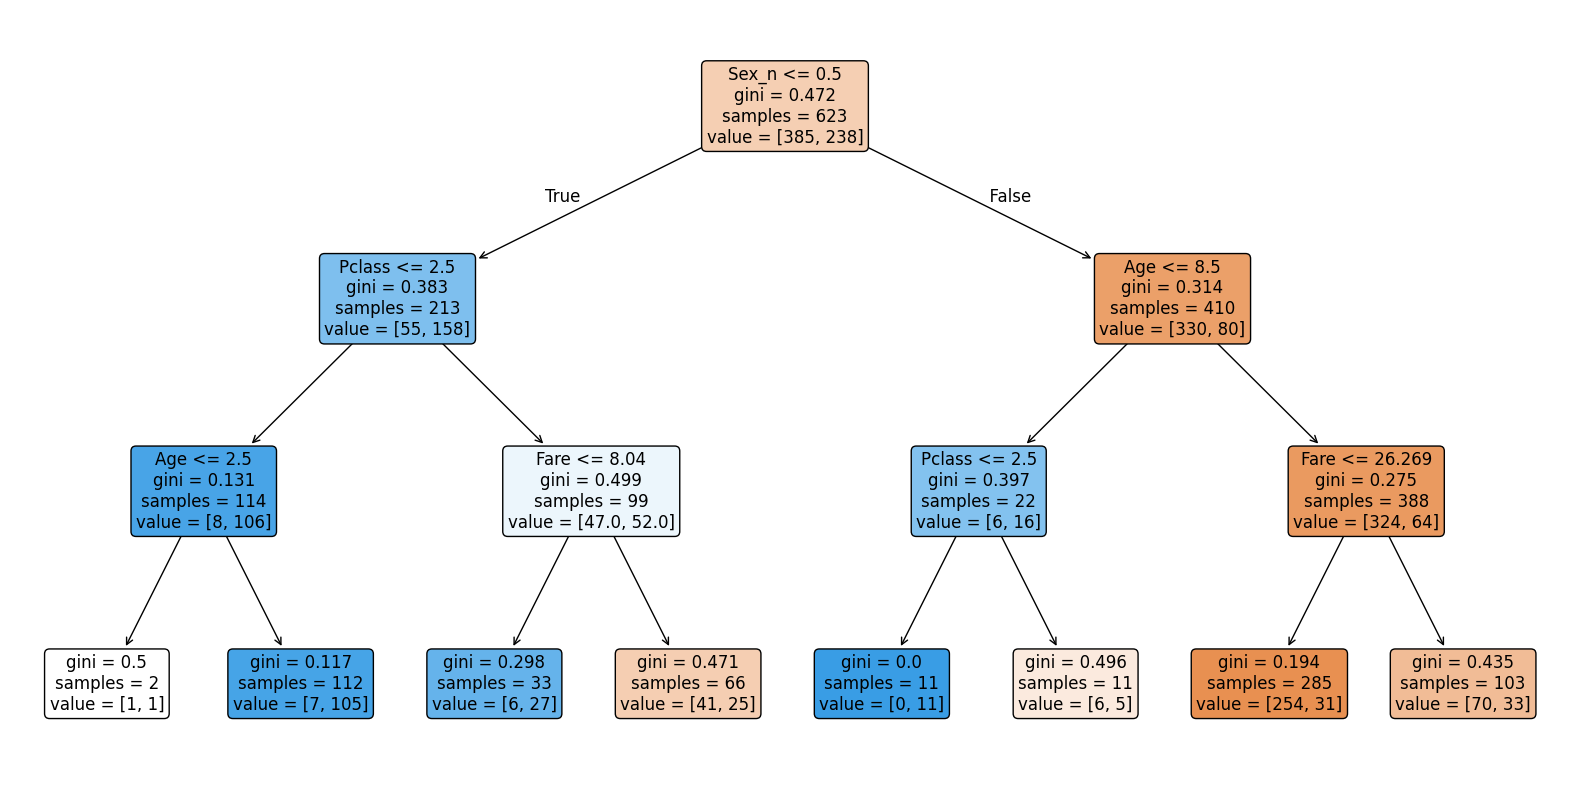

In [19]:
# exercise = Decision tree

import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/tiksha0505/titanicdataset/titanic.csv")
df

target = df['Survived']
inputs = df.drop(['PassengerId', 'Survived', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'Embarked'], axis='columns')
inputs

# implement label encoding only for 'sex'
from sklearn.preprocessing import LabelEncoder
le_sex = LabelEncoder()

inputs['Sex_n'] = le_sex.fit_transform(inputs['Sex'])
# inputs 1 for male and 0 for female

inputs_n = inputs.drop('Sex', axis='columns')
inputs_n

inputs_n['Age'] = inputs_n['Age'].fillna(inputs_n['Age'].median())

# Let's create train_test_split

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(inputs_n, target, test_size=0.3)
# len(X_train) = 623
# len(X_test) = 268
# len(inputs_n) = 891

# create model
from sklearn import tree
model = tree.DecisionTreeClassifier(max_depth = 3)

model.fit(X_train, Y_train)

# model.score(X_train, Y_train) = 0.9823434991974318
# model.predict(X_test)
# array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
#        1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
#        0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
#        1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
#        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
#        0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
#        1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
#        0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
#        1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
#        1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
#        0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
#        0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
#        0, 1, 0, 1])

# model.score(X_test, Y_test) = 0.7686567164179104 before max_depth and median
# model.score(X_test, Y_test) = 0.835820895522388

# visualize the tree
plt.figure(figsize=(20, 10))
tree.plot_tree(
    model, 
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=12
)

# decision tree evaluation
# left side = females sex=0 <= 0.5, right = males = 1, sex>=0.5

In [31]:
# Support Vector Machine

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
iris = load_iris()

# dir(iris)
# ['DESCR',
#  'data',
#  'data_module',
#  'feature_names',
#  'filename',
#  'frame',
#  'target',
#  'target_names']

# iris.feature_names
# ['sepal length (cm)',
#  'sepal width (cm)',
#  'petal length (cm)',
#  'petal width (cm)']

# iris.target_names = array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

# iris.data is a 2D array
# iris.data

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

df['target'] = iris.target
df

# df[df.target==1].head() 50-100
df['flower_names'] = df.target.apply(lambda x: iris.target_names[x])
df

df0 = df[:50]
df1 = df[50:100]
df2 = df[100:]

# plt.xlabel('Sepal Length')
# plt.ylabel('Sepal Width')
# plt.title('Sepal Info')
# plt.scatter(df0['sepal length (cm)'], df0['sepal width (cm)'], marker='+', color='red')
# plt.scatter(df1['sepal length (cm)'], df1['sepal width (cm)'], marker='.', color='blue')
# plt.show()


# plt.xlabel('Petal Length')
# plt.ylabel('Petal Width')
# plt.title('Petal Info')
# plt.scatter(df0['petal length (cm)'], df0['petal width (cm)'], marker='+', color='red')
# plt.scatter(df1['petal length (cm)'], df1['petal width (cm)'], marker='.', color='blue')
# plt.show()

from sklearn.model_selection import train_test_split
X = df.drop(['target', 'flower_names'], axis='columns')
Y = df.target

X_train ,X_test,Y_train,Y_test = train_test_split(X, Y, test_size=0.2)
# X_train
# Y_train

from sklearn.svm import SVC
model = SVC()

model.fit(X_train, Y_train)

# model.score(X_test, Y_test) = 1.0
# model.score(X_train, Y_train) = 0.9833333333333333

model.predict([[6.4, 3.2, 4.5, 1.5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([1])

In [73]:
import pandas as pd 
from sklearn.datasets import load_digits
import seaborn as sn
import matplotlib.pyplot as plt

digits = load_digits()

# dir(digits) = ['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']
# digits.target_names

# plt.figure(figsize=(10, 8))
# sn.heatmap(digits.images[0], annot=True, cmap='gray')
# plt.title('Image Visualization')

df = pd.DataFrame(digits.data, columns=digits.feature_names)
df.head()

df['target'] = digits.target
df

X = df.drop('target', axis='columns')
Y = df['target']

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

from sklearn.svm import SVC
model = SVC()
model.fit(X_train, Y_train)

# model.score(X_train, Y_train)= 0.9972164231036882
# model.score(X_test, Y_test) = 0.9777777777777777

model_linear = SVC(kernel='linear')
model_linear.fit(X_train, Y_train)
# model_linear.score(X_train, Y_train) = 1.0
# model_linear.score(X_test, Y_test) = 0.9777777777777777

model_rbf = SVC(kernel='rbf')
model_rbf.fit(X_train, Y_train)
# model_rbf.score(X_train, Y_train) = 0.9972164231036882

model_strict = SVC(C = 60)
model_strict.fit(X_train, Y_train)
model_strict.score(X_train, Y_train)

# C=1 => 0.9972164231036882
# c=2 => 0.9986082115518441
# C=3 => 1.0
# C=4 => 1.0
# C=5---60+ = 1.0

model_gamma = SVC(gamma=0.01)
model_gamma.fit(X_train, Y_train)
model_gamma.score(X_train, Y_train)

0.9986082115518441

Text(95.72222222222221, 0.5, 'Truth')

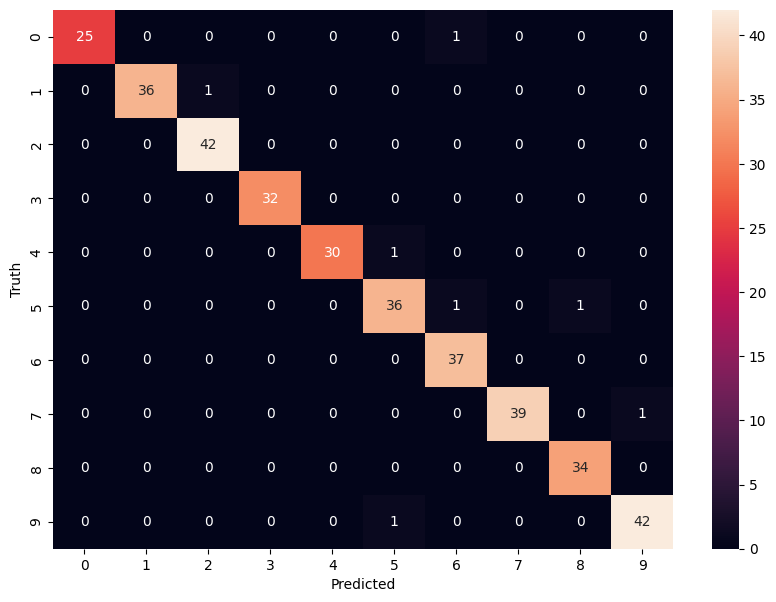

In [27]:
# 15-04-2026
# RANDOM FOREST ALGORTIHM

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
digits = load_digits()

# digits
# plt.gray()
# for i in range(4):
#     plt.matshow(digits.images[i])

df = pd.DataFrame(digits.data)
df.head()

df['target'] = digits.target
df

X = df.drop('target', axis='columns')
Y = df.target

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)


# len(X_train) =1437
# len(X_test) = 360

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, Y_train)

# model.score(X_train, Y_train) = 1.0
# model.score(X_test, Y_test) = 0.975 -> 100trees

# model.score(X_test, Y_test) = 0.9805555555555555 -> 1000trees
# model.score(X_test, Y_test) = 0.9861111111111112

# confusion matrix

Y_predicted = model.predict(X_test)
# Y_predicted
# array([6, 1, 9, 8, 3, 0, 1, 4, 4, 2, 8, 6, 5, 1, 9, 6, 4, 9, 4, 9, 0, 7,
#        2, 6, 5, 6, 2, 1, 4, 4, 8, 6, 7, 4, 9, 8, 4, 8, 5, 2, 0, 5, 4, 9,
#        1, 7, 3, 5, 6, 0, 4, 5, 1, 2, 7, 8, 0, 4, 0, 7, 7, 8, 5, 9, 0, 0,
#        3, 1, 3, 5, 6, 4, 0, 3, 2, 0, 3, 6, 1, 3, 3, 9, 7, 0, 4, 6, 9, 0,
#        1, 5, 1, 7, 0, 3, 3, 7, 2, 9, 4, 6, 4, 3, 0, 5, 4, 4, 7, 7, 3, 7,
#        4, 7, 7, 3, 9, 1, 4, 9, 6, 0, 6, 5, 1, 2, 2, 0, 2, 4, 4, 6, 9, 2,
#        0, 9, 8, 9, 9, 3, 5, 6, 4, 7, 6, 7, 2, 1, 4, 2, 1, 9, 8, 9, 2, 9,
#        3, 9, 4, 5, 4, 3, 7, 0, 3, 1, 9, 6, 7, 8, 2, 7, 6, 4, 0, 4, 1, 9,
#        0, 7, 3, 8, 6, 7, 8, 7, 6, 1, 6, 7, 9, 2, 9, 0, 6, 8, 5, 0, 8, 5,
#        4, 1, 1, 5, 2, 7, 3, 2, 4, 2, 3, 8, 6, 2, 4, 7, 5, 9, 9, 7, 1, 2,
#        5, 7, 0, 5, 1, 1, 3, 3, 5, 8, 8, 8, 5, 6, 9, 1, 6, 5, 2, 7, 7, 4,
#        3, 6, 9, 5, 3, 5, 6, 1, 9, 9, 3, 2, 0, 2, 5, 0, 4, 0, 5, 3, 1, 2,
#        0, 9, 6, 7, 1, 6, 7, 6, 8, 3, 8, 9, 7, 4, 4, 4, 0, 1, 6, 0, 5, 7,
#        2, 4, 1, 3, 6, 8, 1, 6, 8, 1, 8, 2, 7, 8, 6, 5, 4, 1, 8, 3, 2, 5,
#        2, 2, 8, 8, 8, 0, 6, 0, 9, 2, 3, 0, 7, 0, 7, 4, 9, 9, 2, 0, 6, 8,
#        0, 6, 4, 4, 5, 4, 8, 7, 6, 2, 5, 3, 9, 5, 0, 6, 4, 0, 5, 2, 4, 1,
#        9, 4, 0, 1, 2, 3, 8, 7])

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_predicted, Y_test)
# cm
# array([[36,  0,  0,  0,  0,  0,  0,  0,  0,  0],
#        [ 0, 37,  0,  0,  0,  0,  0,  0,  2,  0],
#        [ 0,  0, 30,  0,  0,  0,  0,  0,  0,  0],
#        [ 0,  0,  0, 35,  0,  0,  0,  0,  0,  0],
#        [ 0,  0,  0,  0, 37,  0,  0,  0,  0,  0],
#        [ 0,  0,  0,  0,  0, 38,  0,  0,  0,  1],
#        [ 0,  0,  0,  0,  0,  0, 37,  0,  0,  0],
#        [ 0,  0,  0,  0,  1,  0,  0, 29,  1,  1],
#        [ 0,  0,  0,  1,  0,  1,  0,  0, 34,  0],
#        [ 0,  0,  0,  0,  0,  1,  0,  0,  0, 38]])

import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True)

plt.xlabel('Predicted')
plt.ylabel('Truth')
